In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [1]:
import os
import pandas as pd
import numpy as np

print("--- Project Datasets ---")
input_path = '/kaggle/input'

if os.path.exists(input_path):
    subdirs = os.listdir(input_path)
    if subdirs:
        for subdir in subdirs:
            full_path = os.path.join(input_path, subdir)
            file_count = sum([len(files) for r, d, files in os.walk(full_path)])
            print(f"Dataset Folder: {subdir} ({file_count} files found)")
    else:
        print("Input directory is empty.")
else:
    print("Running in a local environment outside of Kaggle.")

--- Project Datasets ---
Dataset Folder: neu-surface-defect-database (3600 files found)


In [2]:
import numpy as np
print(f"NumPy version: {np.__version__}")

import torch
print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")

NumPy version: 1.26.4
PyTorch version: 2.6.0+cu124
CUDA available: True


In [3]:
%%capture
!pip install --upgrade --force-reinstall numpy==1.26.4 protobuf==4.25.9

In [4]:
import numpy as np
import tensorflow as tf

print(f"NumPy version: {np.__version__}")
print(f"TensorFlow version: {tf.__version__}")

2026-06-18 10:11:37.557416: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1781777497.579227     245 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1781777497.585952     245 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


NumPy version: 1.26.4
TensorFlow version: 2.18.0


In [6]:
import os
import shutil
import random
from tqdm import tqdm

import tensorflow as tf
import numpy as np

import matplotlib.pyplot as plt

from keras.models import Sequential
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from keras.preprocessing import image
from keras.layers import *

import albumentations as A
import cv2
import xml.etree.ElementTree as ET
import torch
from torch.utils.data import Dataset, DataLoader

import warnings
warnings.filterwarnings('ignore')

In [7]:
train_images = "/kaggle/input/neu-surface-defect-database/NEU-DET/train/images"
val_images = "/kaggle/input/neu-surface-defect-database/NEU-DET/validation/images" 
test_images = "/kaggle/input/neu-surface-defect-database/NEU-DET/test/images"

print("Train path exists:", os.path.exists(train_images))
print("Validation path exists:", os.path.exists(val_images)) 
print("Test path exists:", os.path.exists(test_images))

Train path exists: True
Validation path exists: True
Test path exists: False


In [8]:
img_classes=os.listdir(train_images)
print(img_classes)

['inclusion', 'scratches', 'pitted_surface', 'patches', 'crazing', 'rolled-in_scale']


In [9]:
img_classes[0]

'inclusion'

In [10]:
fol_imgs_path = train_images + '/'+ img_classes[0]

img_in_fol = os.listdir(fol_imgs_path)
img_in_fol[0]

'inclusion_1.jpg'

In [11]:
fol_imgs_path + '/' + img_in_fol[0]

'/kaggle/input/neu-surface-defect-database/NEU-DET/train/images/inclusion/inclusion_1.jpg'

In [13]:
def plot_classes(path_,img_classes):
    plt.figure(figsize = (12,12))
    for i,cat in enumerate(img_classes):
        fol_imgs_path = path_ + '/'+ cat
        img_in_fol = os.listdir(fol_imgs_path)

        first_img = img_in_fol[0]
        first_img_path = fol_imgs_path +'/' + first_img

        img_ = image.load_img(first_img_path)
        img_array = image.img_to_array(img_)/255

        plt.subplot(4,4,i+1)
        plt.imshow(img_array)
        plt.title(cat)
        plt.axis('off')
    plt.show()
    

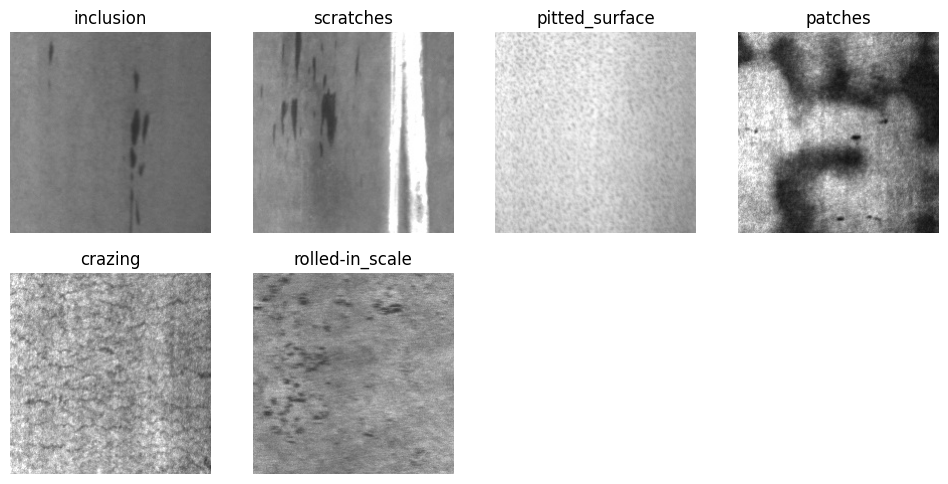

In [14]:
plot_classes(train_images, img_classes)

In [28]:
val_images_path = "/kaggle/input/neu-surface-defect-database/NEU-DET/validation/images"
val_annotations_path = "/kaggle/input/neu-surface-defect-database/NEU-DET/validation/annotations"

# 1. Check Images Structure
print("Checking validation images structure:")
if os.path.exists(val_images_path):
    items = os.listdir(val_images_path)
    print(f"Found {len(items)} items in validation/images:")
    
    for item in items:
        # If it's a sub-folder, print how many images are inside it
        if os.path.isdir(f"{val_images_path}/{item}"):
            sub_files = os.listdir(f"{val_images_path}/{item}")
            print(f"{item}/ - {len(sub_files)} images")
        else:
            print(item)

# 2. Check Annotations Structure
print("\n Checking validation annotations structure:")
if os.path.exists(val_annotations_path):
    annotation_files = os.listdir(val_annotations_path)
    print(f"Found {len(annotation_files)} annotation files")
    print("Sample annotations:", annotation_files[:5])

Checking validation images structure:
Found 6 items in validation/images:
inclusion/ - 60 images
scratches/ - 60 images
pitted_surface/ - 60 images
patches/ - 60 images
crazing/ - 60 images
rolled-in_scale/ - 60 images

 Checking validation annotations structure:
Found 361 annotation files
Sample annotations: ['scratches_246.xml', 'patches_258.xml', 'crazing_241.xml', 'patches_267.xml', 'crazing_270.xml']


In [27]:
# 1. Paths to where the data is coming from and going to
source_folder = "/kaggle/input/neu-surface-defect-database/NEU-DET/validation"
target_folder = "/kaggle/working/NEU-DET/test"

defect_types = ['crazing', 'inclusion', 'patches', 'pitted_surface', 'rolled-in_scale', 'scratches']

# 2. Fresh start: delete the old test folder if it exists
if os.path.exists(target_folder):
    shutil.rmtree(target_folder)
    print("Deleted existing test folder")

print("Created test directory structure\nCopying validation data to test folder...")

# 3. Copy image folders for each defect type
for defect in tqdm(defect_types, desc="Copying images"):
    shutil.copytree(f"{source_folder}/images/{defect}", f"{target_folder}/images/{defect}", dirs_exist_ok=True)

# 4. Copy annotation XML files
os.makedirs(f"{target_folder}/annotations", exist_ok=True)
for file in tqdm(os.listdir(f"{source_folder}/annotations"), desc="Annotations"):
    if file.endswith('.xml'):
        shutil.copy2(f"{source_folder}/annotations/{file}", f"{target_folder}/annotations/{file}")

print("\n Test folder created with EXACT same structure as train and validation!")

Deleted existing test folder
Created test directory structure
Copying validation data to test folder...


Annotations: 100%|██████████| 361/361 [00:01<00:00, 296.83it/s]


 Test folder created with EXACT same structure as train and validation!


In [26]:
print("Checking created Test folder structure:")
test_path = "/kaggle/working/NEU-DET/test"

# Walk through folders and print them like a clean directory tree
for root, dirs, files in os.walk(test_path):
    # Calculate depth to set indentation
    depth = root.replace(test_path, "").count(os.sep)
    indent = "  " * depth
    print(f"{indent}📁 {os.path.basename(root)}/")
    
    # Print the first 3 files as a sample
    file_indent = "  " * (depth + 1)
    for file in files[:3]:
        print(f"{file_indent}📄 {file}")
        
    # Show how many more files are hidden
    if len(files) > 3:
        print(f"{file_indent}... and {len(files) - 3} more files")

Checking created Test folder structure:
📁 test/
  📁 annotations/
    📄 pitted_surface_291.xml
    📄 pitted_surface_290.xml
    📄 scratches_298.xml
    ... and 358 more files
  📁 images/
    📁 inclusion/
      📄 inclusion_265.jpg
      📄 inclusion_259.jpg
      📄 inclusion_297.jpg
      ... and 57 more files
    📁 pitted_surface/
      📄 pitted_surface_298.jpg
      📄 pitted_surface_267.jpg
      📄 pitted_surface_276.jpg
      ... and 57 more files
    📁 patches/
      📄 patches_264.jpg
      📄 patches_241.jpg
      📄 patches_276.jpg
      ... and 57 more files
    📁 rolled-in_scale/
      📄 rolled-in_scale_259.jpg
      📄 rolled-in_scale_264.jpg
      📄 rolled-in_scale_294.jpg
      ... and 57 more files
    📁 crazing/
      📄 crazing_256.jpg
      📄 crazing_261.jpg
      📄 crazing_266.jpg
      ... and 57 more files
    📁 scratches/
      📄 scratches_287.jpg
      📄 scratches_273.jpg
      📄 scratches_292.jpg
      ... and 57 more files


In [19]:
# Now you have consistent structure for all datasets
train_path = "/kaggle/input/neu-surface-defect-database/NEU-DET/train"
val_path = "/kaggle/input/neu-surface-defect-database/NEU-DET/validation"
test_path = "/kaggle/working/NEU-DET/test"

print("YOLO Dataset Paths:")
print(f"Train: {train_path}")
print(f"Validation: {val_path}")
print(f"Test: {test_path}")

# For image data generators, use:
train_images = "/kaggle/input/neu-surface-defect-database/NEU-DET/train/images"
val_images = "/kaggle/input/neu-surface-defect-database/NEU-DET/validation/images"
test_images = "/kaggle/working/NEU-DET/test/images"

YOLO Dataset Paths:
Train: /kaggle/input/neu-surface-defect-database/NEU-DET/train
Validation: /kaggle/input/neu-surface-defect-database/NEU-DET/validation
Test: /kaggle/working/NEU-DET/test


In [25]:
test_path = "/kaggle/working/NEU-DET/test"

print(" Test folder structure after reorganization:")
for class_name in os.listdir(test_path + '/images'):
    if os.path.isdir(test_path + '/images/' + class_name):
        images = os.listdir(test_path + '/images/' + class_name)
        print(f"  {class_name}: {len(images)} images")

 Test folder structure after reorganization:
  inclusion: 60 images
  pitted_surface: 60 images
  patches: 60 images
  rolled-in_scale: 60 images
  crazing: 60 images
  scratches: 60 images


In [24]:
# 1. Define Paths
paths = {
    "Train": "/kaggle/input/neu-surface-defect-database/NEU-DET/train",
    "Validation": "/kaggle/input/neu-surface-defect-database/NEU-DET/validation",
    "Test": "/kaggle/working/NEU-DET/test"
}

# 2. Define a simple helper function to count files and folders
def check_split_structure(base_path):
    if not os.path.exists(base_path):
        return "Not found"
    
    # Count how many class directories are inside 'images'
    images_dir = f"{base_path}/images"
    num_classes = len(os.listdir(images_dir)) if os.path.exists(images_dir) else 0
    
    # Count how many XML files are inside 'annotations'
    annotations_dir = f"{base_path}/annotations"
    num_annotations = len(os.listdir(annotations_dir)) if os.path.exists(annotations_dir) else 0
    
    return f"  Classes: {num_classes}\n  Annotations: {num_annotations}"

# 3. Print the final summary structure
print("Dataset Structure:")
for split_name, path in paths.items():
    print(f"\n{split_name}:")
    print(check_split_structure(path))

Dataset Structure:

Train:
  Classes: 6
  Annotations: 1439

Validation:
  Classes: 6
  Annotations: 361

Test:
  Classes: 6
  Annotations: 361


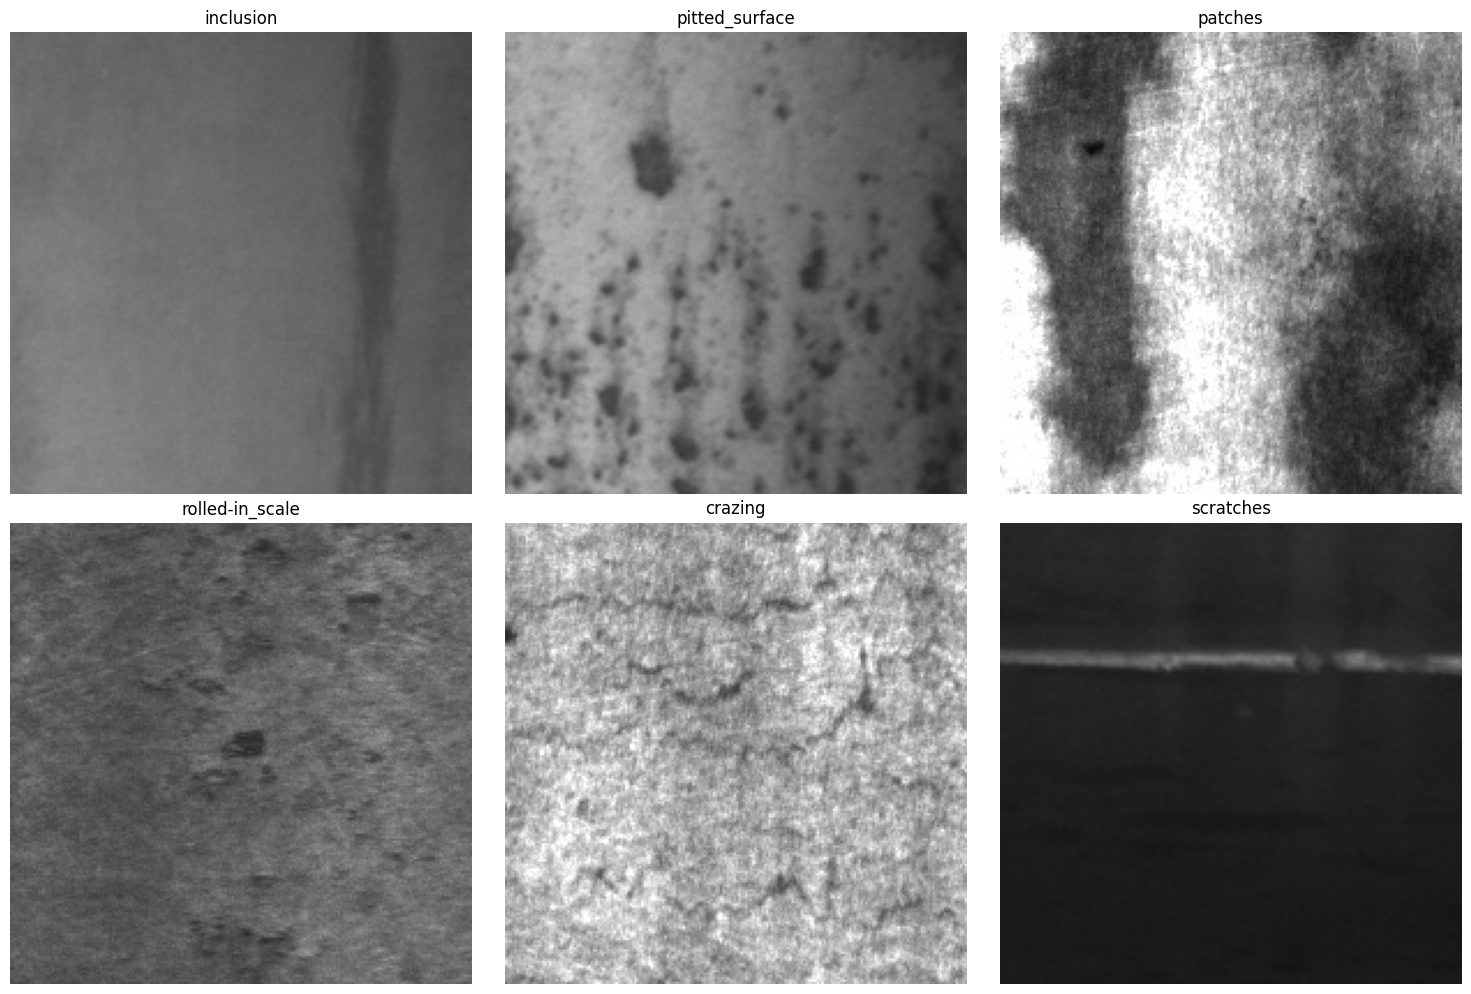

In [23]:
test_images = "/kaggle/working/NEU-DET/test/images"
class_folders = os.listdir(test_images)

# Create a figure grid for the 6 defect classes
plt.figure(figsize=(15, 10))

for idx, class_name in enumerate(class_folders):
    class_path = f"{test_images}/{class_name}"
    
    if os.path.isdir(class_path):
        # Pick a random image from the folder
        images = os.listdir(class_path)
        random_image = random.choice(images)
        
        # Load and plot the image directly
        img = plt.imread(f"{class_path}/{random_image}")
        
        plt.subplot(2, 3, idx + 1)
        plt.imshow(img)
        plt.title(class_name)
        plt.axis('off')

plt.tight_layout()
plt.show()

In [29]:

train_images = "/kaggle/input/neu-surface-defect-database/NEU-DET/train/images"

# Now list the classes
img_classes = os.listdir(train_images)
print(img_classes)

['inclusion', 'scratches', 'pitted_surface', 'patches', 'crazing', 'rolled-in_scale']


In [30]:
img_classes[0]

'inclusion'

In [31]:
fol_img_path=train_images+'/'+img_classes[0]
img_in_fol=os.listdir(fol_img_path)
img_in_fol[0]

'inclusion_1.jpg'

In [32]:
def plot_classes(path_,img_classes):
    plt.figure(figsize = (12,12))
    for i,cat in enumerate(img_classes):
        fol_imgs_path = path_ + '/'+ cat
        img_in_fol = os.listdir(fol_imgs_path)

        first_img = img_in_fol[0]
        first_img_path = fol_imgs_path +'/' + first_img

        img_ = image.load_img(first_img_path)
        img_array = image.img_to_array(img_)/255

        plt.subplot(4,4,i+1)
        plt.imshow(img_array)
        plt.title(cat)
        plt.axis('off')
    plt.show()


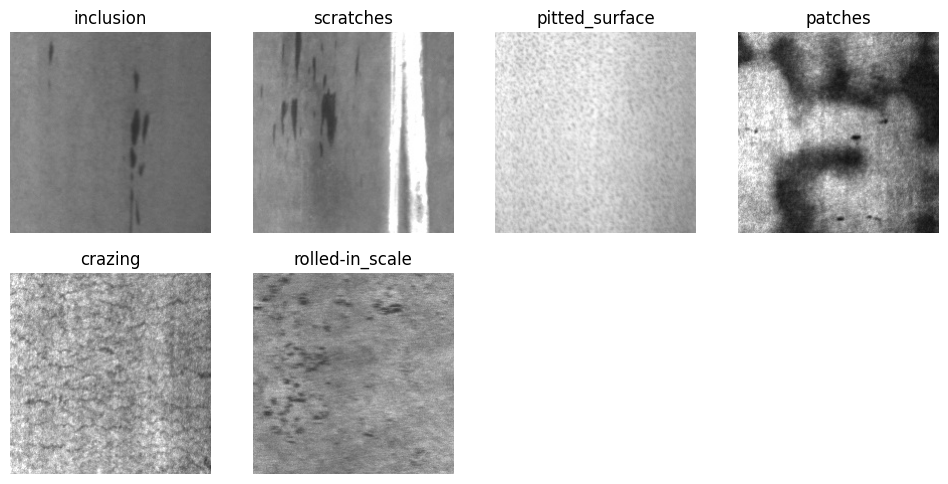

In [33]:
plot_classes(train_images, img_classes)

In [34]:


train_images = "/kaggle/input/neu-surface-defect-database/NEU-DET/train/images"


data_gen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.1,
    height_shift_range=0.1,
    shear_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True,
    fill_mode='nearest'
)

train_data = data_gen.flow_from_directory(
    train_images,
    target_size=(244,244),
    class_mode='categorical',
    batch_size=32,
    shuffle=True
)



Found 1440 images belonging to 6 classes.


In [35]:
test_images = "/kaggle/working/NEU-DET/test/images"

test_data = ImageDataGenerator(rescale=1/255).flow_from_directory(
    test_images,
    target_size=(244,244),
    class_mode='categorical',
    batch_size=32,
    shuffle=False
)

Found 360 images belonging to 6 classes.


In [36]:
val_images = "/kaggle/input/neu-surface-defect-database/NEU-DET/validation/images" 

val_data = ImageDataGenerator(rescale=1./255).flow_from_directory(
    val_images,
    target_size=(244,244),
    class_mode='categorical',
    batch_size=32,
    shuffle=False
)

Found 360 images belonging to 6 classes.


In [37]:
import os

def check_annotation_matches(images_path, annotations_path, split_name):
    print(f"\n{split_name.upper()}:")
    
    total_images = 0
    missing = []
    
    # Iterate through each defect class directory safely
    for class_name in os.listdir(images_path):
        class_dir = f"{images_path}/{class_name}"
        if not os.path.isdir(class_dir):
            continue
            
        for img in os.listdir(class_dir):
            total_images += 1
            
            # Extract base name (e.g., 'crazing_1') and build XML path
            base_name, _ = os.path.splitext(img)
            xml_path = f"{annotations_path}/{base_name}.xml"
            
            if not os.path.exists(xml_path):
                missing.append(img)
                
    print(f"  Total images: {total_images}")
    print(f"  Missing annotations: {len(missing)}")
    
    # Handle output reporting
    if missing:
        print("  Missing files:")
        for img in missing[:5]:
            base, _ = os.path.splitext(img)
            print(f"    {img} -> {base}.xml")
        if len(missing) > 5:
            print(f"    ... and {len(missing) - 5} more")
    else:
        print("  ✅ Perfect! All images have matching annotations")

# 1. Check Input Dataset Splits (Train & Validation)
base_path = '/kaggle/input/neu-surface-defect-database/NEU-DET'
for split in ['train', 'validation']:
    check_annotation_matches(f"{base_path}/{split}/images", f"{base_path}/{split}/annotations", split)

# 2. Check Working Dataset Split (Test)
test_base = '/kaggle/working/NEU-DET/test'
if os.path.exists(f"{test_base}/images"):
    check_annotation_matches(f"{test_base}/images", f"{test_base}/annotations", 'test')
else:
    print("\nTEST: Folder not found")


TRAIN:
  Total images: 1440
  Missing annotations: 1
  Missing files:
    crazing_240.jpg -> crazing_240.xml

VALIDATION:
  Total images: 360
  Missing annotations: 0
  ✅ Perfect! All images have matching annotations

TEST:
  Total images: 360
  Missing annotations: 0
  ✅ Perfect! All images have matching annotations


In [38]:
# 1. Define Standard Paths
train_ann_dir = '/kaggle/input/neu-surface-defect-database/NEU-DET/train/annotations'
val_ann_file  = '/kaggle/input/neu-surface-defect-database/NEU-DET/validation/annotations/crazing_240.xml'
test_ann_file = '/kaggle/working/NEU-DET/test/annotations/crazing_240.xml'

# 2. Search for Variations inside the Train Folder
print("Looking for crazing_240 annotations (variations/typos):")
if os.path.exists(train_ann_dir):
    all_files = os.listdir(train_ann_dir)
    
    # Print any file containing '240' or 'crazing_240'
    for file in all_files:
        if '240' in file or 'crazing_240' in file:
            print(f"  Found matching pattern: {file}")
            
    # Print a quick sorted preview of standard crazing annotations
    print("\n Crazing annotations preview (First 10):")
    crazing_files = sorted([f for f in all_files if 'crazing' in f])
    for file in crazing_files[:10]:
        print(f"  {file}")

# 3. Direct Target Check Across Extensions and Splits
print("\n Target Verification:")
print(f"  Direct check for 'crazing_240.xml' in Train: {os.path.exists(f'{train_ann_dir}/crazing_240.xml')}")
print(f"  Check for lowercase 'crazing_240.txt' in Train: {os.path.exists(f'{train_ann_dir}/crazing_240.txt')}")
print(f"  Check for uppercase 'crazing_240.XML' in Train: {os.path.exists(f'{train_ann_dir}/crazing_240.XML')}")

print(f"\n Cross-Dataset Leak Check:")
print(f"  Exists in Validation: {os.path.exists(val_ann_file)}")
print(f"  Exists in Test:       {os.path.exists(test_ann_file)}")

Looking for crazing_240 annotations (variations/typos):
  Found matching pattern: scratches_240.xml
  Found matching pattern: patches_240.xml
  Found matching pattern: pitted_surface_240.xml
  Found matching pattern: rolled-in_scale_240.xml
  Found matching pattern: inclusion_240.xml

 Crazing annotations preview (First 10):
  crazing_1.xml
  crazing_10.xml
  crazing_100.xml
  crazing_101.xml
  crazing_102.xml
  crazing_103.xml
  crazing_104.xml
  crazing_105.xml
  crazing_106.xml
  crazing_107.xml

 Target Verification:
  Direct check for 'crazing_240.xml' in Train: False
  Check for lowercase 'crazing_240.txt' in Train: False
  Check for uppercase 'crazing_240.XML' in Train: False

 Cross-Dataset Leak Check:
  Exists in Validation: True
  Exists in Test:       True


In [48]:
def check_dataset_health(split_name, base_path):
    print(f"\nChecking {split_name}:\n" + "=" * 50)
    img_dir, ann_dir = f"{base_path}/images", f"{base_path}/annotations"
    
    if not os.path.exists(img_dir) or not os.path.exists(ann_dir):
        print(f"Paths missing for {split_name}"); return

    total_images, missing = 0, []
    total_anns = len([f for f in os.listdir(ann_dir) if f.endswith('.xml')])
    
    for cls in os.listdir(img_dir):
        cls_path = f"{img_dir}/{cls}"
        if not os.path.isdir(cls_path): continue
            
        cls_files = os.listdir(cls_path)
        total_images += len(cls_files)
        
        for img in cls_files:
            xml = f"{os.path.splitext(img)[0]}.xml"
            if not os.path.exists(f"{ann_dir}/{xml}"):
                missing.append((cls, img, xml))
                
    print(f"Summary for {split_name}:\n  Total images: {total_images}\n  Total annotations: {total_anns}\n  Missing annotations: {len(missing)}")
    
    if missing:
        print("  Missing files:")
        for cls, img, xml in missing[:3]:
            print(f"    {cls}/{img} -> {xml}")
        if len(missing) > 3: print(f"    ... and {len(missing) - 3} more")
    else:
        print("  Perfect! All images have annotations.")
        
    print("  Perfect balance!" if total_images == total_anns else f"  Imbalance: {abs(total_images - total_anns)} difference")

# --- Run ---
datasets = {
    'train': '/kaggle/input/neu-surface-defect-database/NEU-DET/train',
    'validation': '/kaggle/input/neu-surface-defect-database/NEU-DET/validation',
    'test': '/kaggle/working/NEU-DET/test'
}

for split, path in datasets.items():
    check_dataset_health(split, path) if os.path.exists(path) else print(f"\n{split} path not found")


Checking train:
Summary for train:
  Total images: 1440
  Total annotations: 1439
  Missing annotations: 1
  Missing files:
    crazing/crazing_240.jpg -> crazing_240.xml
  Imbalance: 1 difference

Checking validation:
Summary for validation:
  Total images: 360
  Total annotations: 361
  Missing annotations: 0
  Perfect! All images have annotations.
  Imbalance: 1 difference

Checking test:
Summary for test:
  Total images: 360
  Total annotations: 360
  Missing annotations: 0
  Perfect! All images have annotations.
  Perfect balance!


In [47]:
def create_fixed_dataset():
    print("Creating fixed datasets in working directory...")
    fixed_base = '/kaggle/working/NEU-DET-fixed'
    
    sources = {
        'train': '/kaggle/input/neu-surface-defect-database/NEU-DET/train',
        'validation': '/kaggle/input/neu-surface-defect-database/NEU-DET/validation',
        'test': '/kaggle/working/NEU-DET/test'
    }
    
    for split, src_path in sources.items():
        print(f"\nProcessing {split}...")
        dst_path = f"{fixed_base}/{split}"
        
        os.makedirs(f"{dst_path}/images", exist_ok=True)
        os.makedirs(f"{dst_path}/annotations", exist_ok=True)
        
        # 1. Copy Images (filtering out train's unmatched image)
        img_count = 0
        for cls in os.listdir(f"{src_path}/images"):
            src_cls_dir = f"{src_path}/images/{cls}"
            dst_cls_dir = f"{dst_path}/images/{cls}"
            os.makedirs(dst_cls_dir, exist_ok=True)
            
            for img in os.listdir(src_cls_dir):
                if split == 'train' and img == 'crazing_240.jpg':
                    continue
                
                shutil.copy2(f"{src_cls_dir}/{img}", f"{dst_cls_dir}/{img}")
                img_count += 1
        
        # 2. Copy Annotations (dropping the extra xml files)
        ann_count = 0
        for xml in os.listdir(f"{src_path}/annotations"):
            if split in ['validation', 'test'] and xml == 'crazing_240.xml':
                continue
                
            shutil.copy2(f"{src_path}/annotations/{xml}", f"{dst_path}/annotations/{xml}")
            ann_count += 1
            
        print(f"   Copied: {img_count} images, {ann_count} annotations")

    print(f"\nFixed datasets created at: {fixed_base}")
    return fixed_base

fixed_base = create_fixed_dataset()

Creating fixed datasets in working directory...

Processing train...
   Copied: 1439 images, 1439 annotations

Processing validation...
   Copied: 360 images, 360 annotations

Processing test...
   Copied: 360 images, 360 annotations

Fixed datasets created at: /kaggle/working/NEU-DET-fixed


In [46]:
def verify_final_datasets():
    print("Final verification:")
    
    datasets = {
        'train': '/kaggle/working/NEU-DET-fixed/train',
        'validation': '/kaggle/working/NEU-DET-fixed/validation', 
        'test': '/kaggle/working/NEU-DET/test'
    }
    
    for name, path in datasets.items():
        if not os.path.exists(path):
            continue
            
        # Count total images across all class subfolders
        img_dir = f"{path}/images"
        images = 0
        for cls in os.listdir(img_dir):
            cls_path = f"{img_dir}/{cls}"
            if os.path.isdir(cls_path):
                images += len(os.listdir(cls_path))
        
        # Count total annotation XML files
        ann_dir = f"{path}/annotations"
        annotations = len(os.listdir(ann_dir)) if os.path.exists(ann_dir) else 0
        
        status = "BALANCED" if images == annotations else "IMBALANCED"
        print(f"{name}: {images} images, {annotations} annotations - {status}")

verify_final_datasets()

Final verification:
train: 1439 images, 1439 annotations - BALANCED
validation: 360 images, 360 annotations - BALANCED
test: 360 images, 360 annotations - BALANCED


In [45]:
def fix_test_annotations():
    print("Fixing test annotations...")
    ann_file = '/kaggle/working/NEU-DET/test/annotations/crazing_240.xml'
    
    # Remove the extra annotation from test split if it exists
    if os.path.exists(ann_file):
        os.remove(ann_file)
        print("Removed from test: crazing_240.xml (extra annotation)")
    else:
        print("crazing_240.xml already removed from test")

fix_test_annotations()

Fixing test annotations...
crazing_240.xml already removed from test


In [44]:
def check_balance():
    print("Checking dataset balance:")
    
    datasets = {
        'train': '/kaggle/working/NEU-DET-fixed/train',
        'validation': '/kaggle/working/NEU-DET-fixed/validation', 
        'test': '/kaggle/working/NEU-DET/test'
    }
    
    for name, path in datasets.items():
        if os.path.exists(path):
            # Count images
            images = 0
            for class_name in os.listdir(os.path.join(path, 'images')):
                class_path = os.path.join(path, 'images', class_name)
                images += len([f for f in os.listdir(class_path) if f.endswith(('.jpg','.png','.jpeg'))])
            
            # Count annotations
            annotations = len([f for f in os.listdir(os.path.join(path, 'annotations')) if f.endswith('.xml')])
            
            print(f"{name}: {images} images, {annotations} annotations - {'BALANCED' if images == annotations else 'IMBALANCED'}")

check_balance()

Checking dataset balance:
train: 1439 images, 1439 annotations - BALANCED
validation: 360 images, 360 annotations - BALANCED
test: 360 images, 360 annotations - BALANCED


In [50]:
import xml.etree.ElementTree as ET

CLASSES = ['crazing', 'inclusion', 'patches', 'pitted_surface', 'rolled-in_scale', 'scratches']

def convert_xml_to_yolo(xml_path, txt_path):
    root = ET.parse(xml_path).getroot()
    
    # Extract image physical dimensions
    width = int(root.find('size/width').text)
    height = int(root.find('size/height').text)
    
    with open(txt_path, 'w') as f:
        for obj in root.findall('object'):
            class_name = obj.find('name').text
            if class_name not in CLASSES:
                continue
            class_id = CLASSES.index(class_name)
            
            # Fetch bounding box edge coordinates
            bndbox = obj.find('bndbox')
            xmin = int(bndbox.find('xmin').text)
            ymin = int(bndbox.find('ymin').text)
            xmax = int(bndbox.find('xmax').text)
            ymax = int(bndbox.find('ymax').text)
            
            # Convert absolute pixel boundaries to relative YOLO format
            x_center = (xmin + xmax) / 2 / width
            y_center = (ymin + ymax) / 2 / height
            w = (xmax - xmin) / width
            h = (ymax - ymin) / height
            
            f.write(f"{class_id} {x_center:.6f} {y_center:.6f} {w:.6f} {h:.6f}\n")

# --- Execute Batch Conversion ---
datasets = {
    'train': '/kaggle/working/NEU-DET-fixed/train',
    'validation': '/kaggle/working/NEU-DET-fixed/validation',
    'test': '/kaggle/working/NEU-DET/test'
}

for split, base_path in datasets.items():
    ann_dir = f"{base_path}/annotations"
    lbl_dir = f"{base_path}/labels"
    os.makedirs(lbl_dir, exist_ok=True)
    
    for xml_file in os.listdir(ann_dir):
        if xml_file.endswith('.xml'):
            base_name, _ = os.path.splitext(xml_file)
            convert_xml_to_yolo(
                xml_path=f"{ann_dir}/{xml_file}",
                txt_path=f"{lbl_dir}/{base_name}.txt"
            )
            
    print(f"Converted {split} split successfully.")
print("All conversions completed.")

Converted train split successfully.
Converted validation split successfully.
Converted test split successfully.
All conversions completed.


In [51]:
def verify_conversion():
    print("Verifying conversion:")
    
    datasets = {
        'train': '/kaggle/working/NEU-DET-fixed/train',
        'validation': '/kaggle/working/NEU-DET-fixed/validation', 
        'test': '/kaggle/working/NEU-DET/test'
    }
    
    for name, path in datasets.items():
        if not os.path.exists(path):
            continue
            
        print(f"\n{name}:")
        img_dir, lbl_dir = f"{path}/images", f"{path}/labels"
        
        # 1. Gather all unique label base names (without .txt)
        label_bases = set()
        if os.path.exists(lbl_dir):
            label_bases = {os.path.splitext(f)[0] for f in os.listdir(lbl_dir) if f.endswith('.txt')}
            
        # 2. Count images and check for missing label equivalents
        images_count = 0
        missing_labels = 0
        
        for cls in os.listdir(img_dir):
            cls_path = f"{img_dir}/{cls}"
            if not os.path.isdir(cls_path):
                continue
                
            for img in os.listdir(cls_path):
                images_count += 1
                img_base, _ = os.path.splitext(img)
                
                # Check if this image has a corresponding label entry
                if img_base not in label_bases:
                    missing_labels += 1
                    
        labels_count = len(label_bases)
        status = 'OK' if images_count == labels_count else 'MISMATCH'
        
        print(f"  Images: {images_count}")
        print(f"  Labels: {labels_count}")
        print(f"  Status: {status}")
        print("  All images have labels" if missing_labels == 0 else f"  Missing labels: {missing_labels}")

verify_conversion()

Verifying conversion:

train:
  Images: 1439
  Labels: 1439
  Status: OK
  All images have labels

validation:
  Images: 360
  Labels: 360
  Status: OK
  All images have labels

test:
  Images: 360
  Labels: 360
  Status: OK
  All images have labels


In [52]:
base_path = '/kaggle/working/NEU-DET-fixed'

yaml_content = f"""
path: {base_path}
train: train/images
val: validation/images  
test: test/images

nc: 6
names: ['crazing', 'inclusion', 'patches', 'pitted_surface', 'rolled-in_scale', 'scratches']
"""

with open(f'{base_path}/dataset.yaml', 'w') as f:
    f.write(yaml_content.strip())

print("dataset.yaml created successfully with clean relative splits.")

dataset.yaml created successfully with clean relative splits.


In [53]:
import os
import shutil

# 1. Clean up old directory
old_path = '/kaggle/working/NEU-DET'
if os.path.exists(old_path):
    shutil.rmtree(old_path)
    print("Deleted old NEU-DET folder to avoid confusion.")
else:
    print("Old NEU-DET folder already removed.")

# 2. Print clean structure summary
print("\nFinal clean structure:")
base_dir = '/kaggle/working'

if os.path.exists(base_dir):
    for item in sorted(os.listdir(base_dir)):
        item_path = f"{base_dir}/{item}"
        
        # Only show folders related to your dataset working directories
        if os.path.isdir(item_path) and item.startswith('NEU-DET'):
            print(f"{item}/")
            for subitem in sorted(os.listdir(item_path)):
                if os.path.isdir(f"{item_path}/{subitem}"):
                    print(f"  └── {subitem}/")

Deleted old NEU-DET folder to avoid confusion.

Final clean structure:
NEU-DET-fixed/
  └── test/
  └── train/
  └── validation/


In [55]:
# Check if the folder actually exists in filesystem
old_path = '/kaggle/working/NEU-DET'
if os.path.exists(old_path):
    print(" Folder still exists in filesystem")
else:
    print(" Folder successfully deleted from filesystem")

# List what's actually in working directory
print("\nActual contents of /kaggle/working/:")
for item in os.listdir('/kaggle/working/'):
    print(f"  {item}")

 Folder successfully deleted from filesystem

Actual contents of /kaggle/working/:
  .virtual_documents
  NEU-DET-fixed


In [58]:
import os
from IPython.display import display, HTML

zip_path = '/kaggle/working/NEU_DET_YOLO_Permanent.zip'

if os.path.exists(zip_path):
    file_size_mb = os.path.getsize(zip_path) / (1024 * 1024)
    print(f"Archive found. Size: {file_size_mb:.2f} MB")
    
    # Force a direct relative HTML link injection instead of IPython FileLink
    html_link = '<a href="./NEU_DET_YOLO_Permanent.zip" download>Click Here to Download Your YOLO Dataset Archive</a>'
    display(HTML(html_link))
else:
    print("Archive file not found. Please re-run your compression step first.")

Archive found. Size: 31.82 MB
